In [1]:
# Lab 5

In [2]:
# ============================================
# LAB ASSIGNMENT 5
# MULTICLASS CLASSIFICATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

# Dataset splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

print("Uploaded file:")
for filename in uploaded.keys():
    print(filename)

Saving dermatology_database_1.csv to dermatology_database_1 (1).csv
Uploaded file:
dermatology_database_1 (1).csv


In [4]:
# Find uploaded filename
filename = list(uploaded.keys())[0]

# Load data
df = pd.read_csv(
    filename,
    header=None,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (367, 35)


In [5]:
feature_names = [
    "erythema",
    "scaling",
    "definite_borders",
    "itching",
    "koebner_phenomenon",
    "polygonal_papules",
    "follicular_papules",
    "oral_mucosal_involvement",
    "knee_and_elbow_involvement",
    "scalp_involvement",
    "family_history",
    "melanin_incontinence",
    "eosinophils_infiltrate",
    "PNL_infiltrate",
    "fibrosis_papillary_dermis",
    "exocytosis",
    "acanthosis",
    "hyperkeratosis",
    "parakeratosis",
    "clubbing_rete_ridges",
    "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis",
    "spongiform_pustule",
    "munro_microabcess",
    "focal_hypergranulosis",
    "disappearance_granular_layer",
    "vacuolisation_basal_layer",
    "spongiosis",
    "saw_tooth_appearance",
    "follicular_horn_plug",
    "perifollicular_parakeratosis",
    "inflammatory_monoluclear_infiltrate",
    "band_like_infiltrate",
    "age",
    "class"
]

df.columns = feature_names

print("Column names added successfully!")

Column names added successfully!


In [6]:
display(df.head())

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_basal_layer,spongiosis,saw_tooth_appearance,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
1,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
2,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
3,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
4,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1


In [7]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (367, 35)

Column names:
['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_granular_layer', 'vacuolisation_basal_layer', 'spongiosis', 'saw_tooth_appearance', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_monoluclear_infiltrate', 'band_like_infiltrate', 'age', 'class']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   erythema                             367 non-null    object
 1   scaling                              367 non-null    object
 2   definite_borders                     367 non-null    object
 3   itching                              367 non-null    object
 4   koebner_phenomenon                   367 non-null    object
 5   polygonal_papules                    367 non-null    object
 6   follicular_papules                   367 non-null    object
 7   oral_mucosal_involvement             367 non-null    object
 8   knee_and_elbow_involvement           367 non-null    object
 9   scalp_involvement                    367 non-null    object
 10  family_history                       367 non-null    object
 11  melanin_incontinence                 367 non-

In [9]:
print("SUMMARY STATISTICS")
print("=" * 50)

display(df.describe())

SUMMARY STATISTICS


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_basal_layer,spongiosis,saw_tooth_appearance,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
count,367,367,367,367,367,367,367,367,367,367,...,367,367,367,367,367,367,367,367,359,367
unique,5,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,61,7
top,2,2,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,40,1
freq,215,195,168,118,224,297,333,299,251,264,...,273,294,199,294,344,345,206,289,17,112


In [10]:
print("MEAN")
display(df.mean(numeric_only=True))

print("MEDIAN")
display(df.median(numeric_only=True))

print("STANDARD DEVIATION")
display(df.std(numeric_only=True))

MEAN


,0


MEDIAN


,0


STANDARD DEVIATION


,0


In [11]:
print("Missing values per column:")
missing = df.isnull().sum()

display(missing[missing > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:


,0
age,8



Total missing values: 8


In [13]:
# Fill missing values using median
for column in df.columns:
    if column != "class":
        # Convert column to numeric, coercing errors to NaN
        df[column] = pd.to_numeric(df[column], errors='coerce')
        # Fill missing values with the median of the now numeric column
        df[column] = df[column].fillna(df[column].median())

print(
    "Total missing values after handling:",
    df.isnull().sum().sum()
)

Total missing values after handling: 0


In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (367, 35)


In [16]:
print("Minimum and maximum values:")
display(
    pd.DataFrame({
        "Minimum": df.drop(columns=["class"]).min(),
        "Maximum": df.drop(columns=["class"]).max()
    })
)

Minimum and maximum values:


,Minimum,Maximum
erythema,0.0,3.0
scaling,0.0,3.0
definite_borders,0.0,3.0
itching,0.0,3.0
koebner_phenomenon,0.0,3.0
polygonal_papules,0.0,3.0
follicular_papules,0.0,3.0
oral_mucosal_involvement,0.0,3.0
knee_and_elbow_involvement,0.0,3.0
scalp_involvement,0.0,3.0


In [17]:
class_counts = df["class"].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

Class distribution:
class
1        112
2         61
3         72
4         49
5         52
6         20
class      1
Name: count, dtype: int64


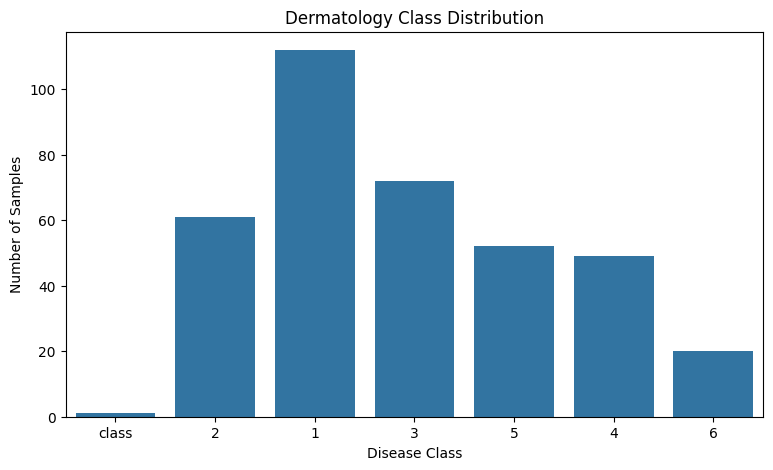

In [18]:
plt.figure(figsize=(9, 5))

sns.countplot(
    x="class",
    data=df
)

plt.title("Dermatology Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.show()

In [20]:
# Convert 'class' column to numeric, coercing errors to NaN
df['class'] = pd.to_numeric(df['class'], errors='coerce')

# Drop rows where 'class' is NaN (these were the non-numeric entries)
df.dropna(subset=['class'], inplace=True)

# Convert 'class' column to integer type
df['class'] = df['class'].astype(int)

class_names = {
    1: "Psoriasis",
    2: "Seboreic dermatitis",
    3: "Lichen planus",
    4: "Pityriasis rosea",
    5: "Cronic dermatitis",
    6: "Pityriasis rubra pilaris"
}

class_distribution = df["class"].value_counts().sort_index()

for class_id, count in class_distribution.items():
    print(
        f"Class {class_id}: "
        f"{class_names[class_id]} → {count} samples"
    )

Class 1: Psoriasis → 112 samples
Class 2: Seboreic dermatitis → 61 samples
Class 3: Lichen planus → 72 samples
Class 4: Pityriasis rosea → 49 samples
Class 5: Cronic dermatitis → 52 samples
Class 6: Pityriasis rubra pilaris → 20 samples


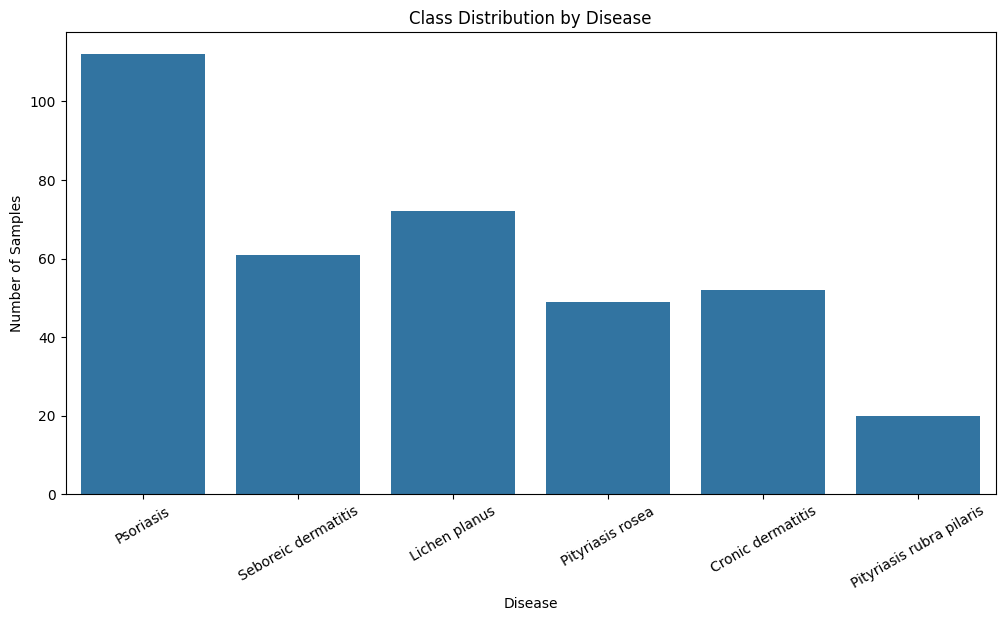

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=[
        class_names[i]
        for i in class_distribution.index
    ],
    y=class_distribution.values
)

plt.title("Class Distribution by Disease")
plt.xlabel("Disease")
plt.ylabel("Number of Samples")

plt.xticks(rotation=30)

plt.show()

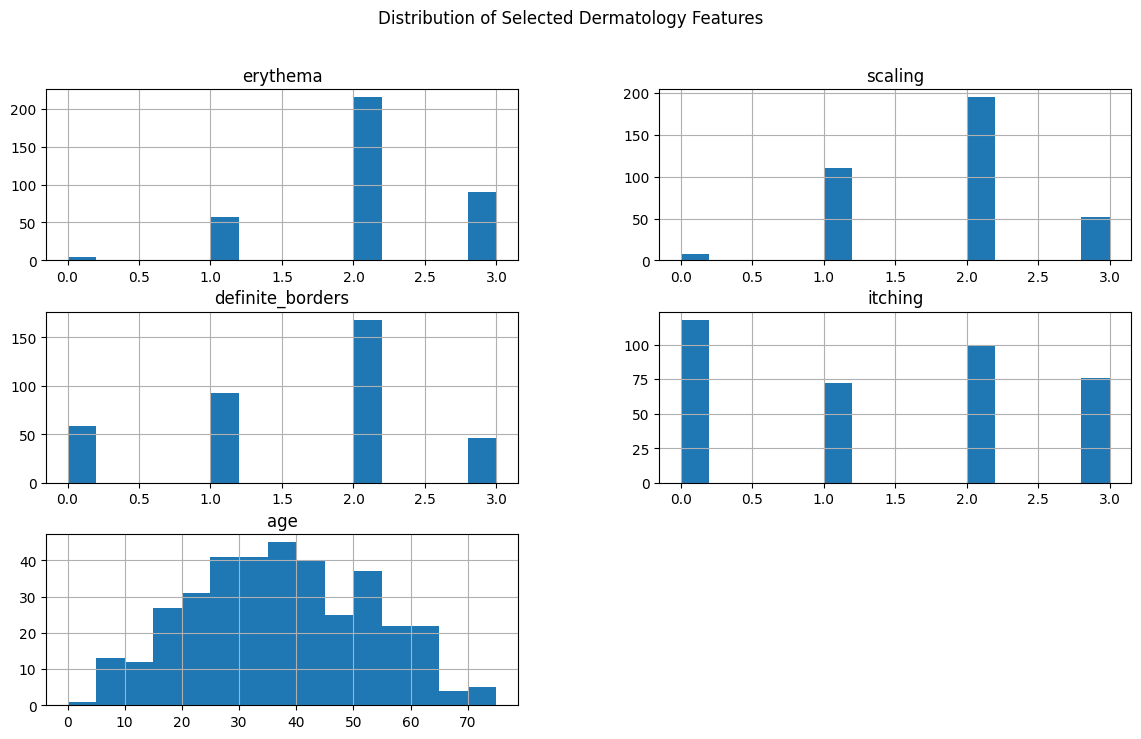

In [22]:
selected_features = [
    "erythema",
    "scaling",
    "definite_borders",
    "itching",
    "age"
]

df[selected_features].hist(
    figsize=(14, 8),
    bins=15
)

plt.suptitle(
    "Distribution of Selected Dermatology Features"
)

plt.show()

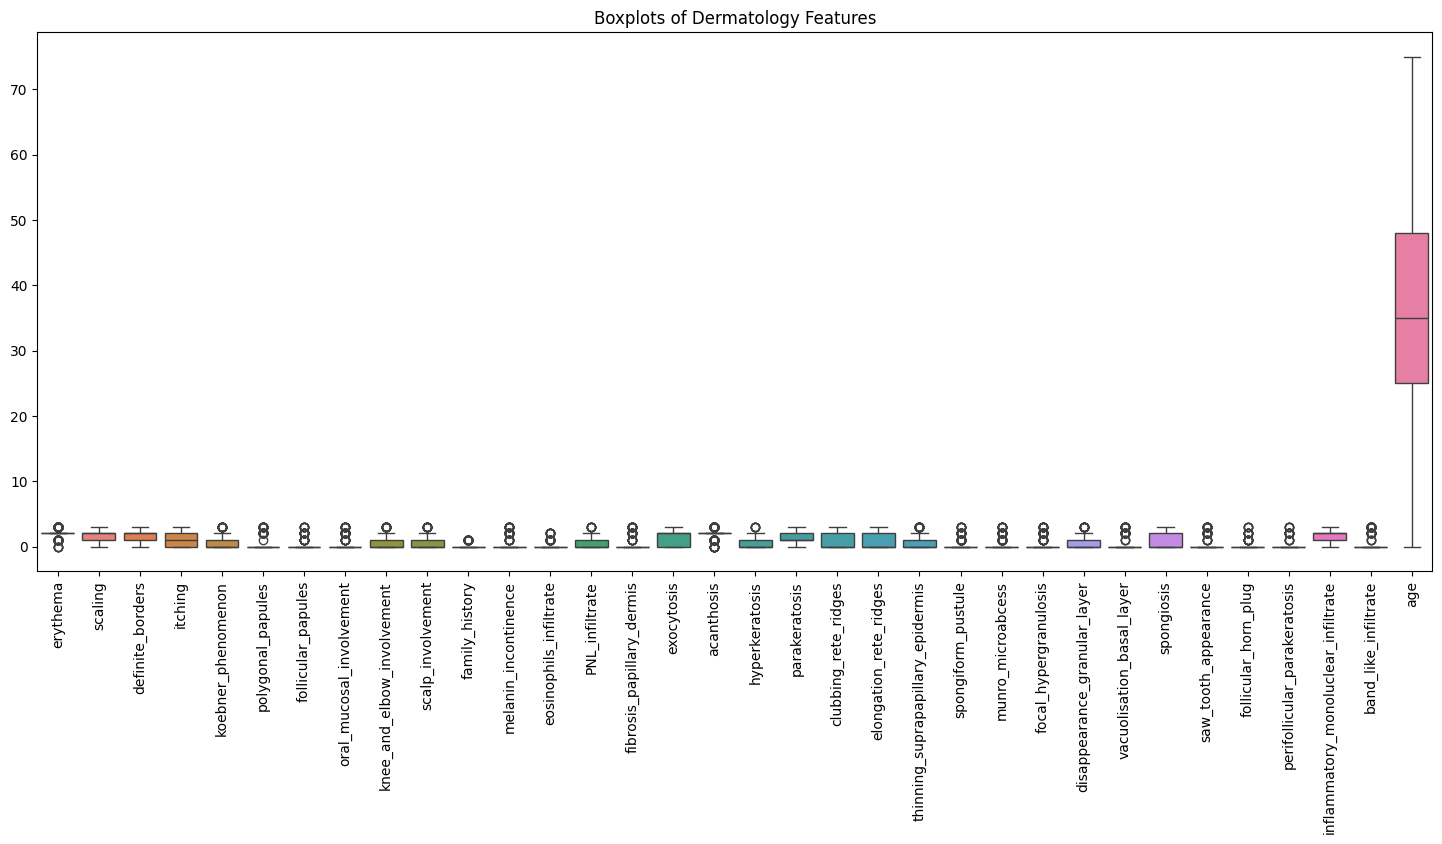

In [23]:
plt.figure(figsize=(18, 7))

sns.boxplot(
    data=df.drop(columns=["class"])
)

plt.title("Boxplots of Dermatology Features")

plt.xticks(rotation=90)

plt.show()

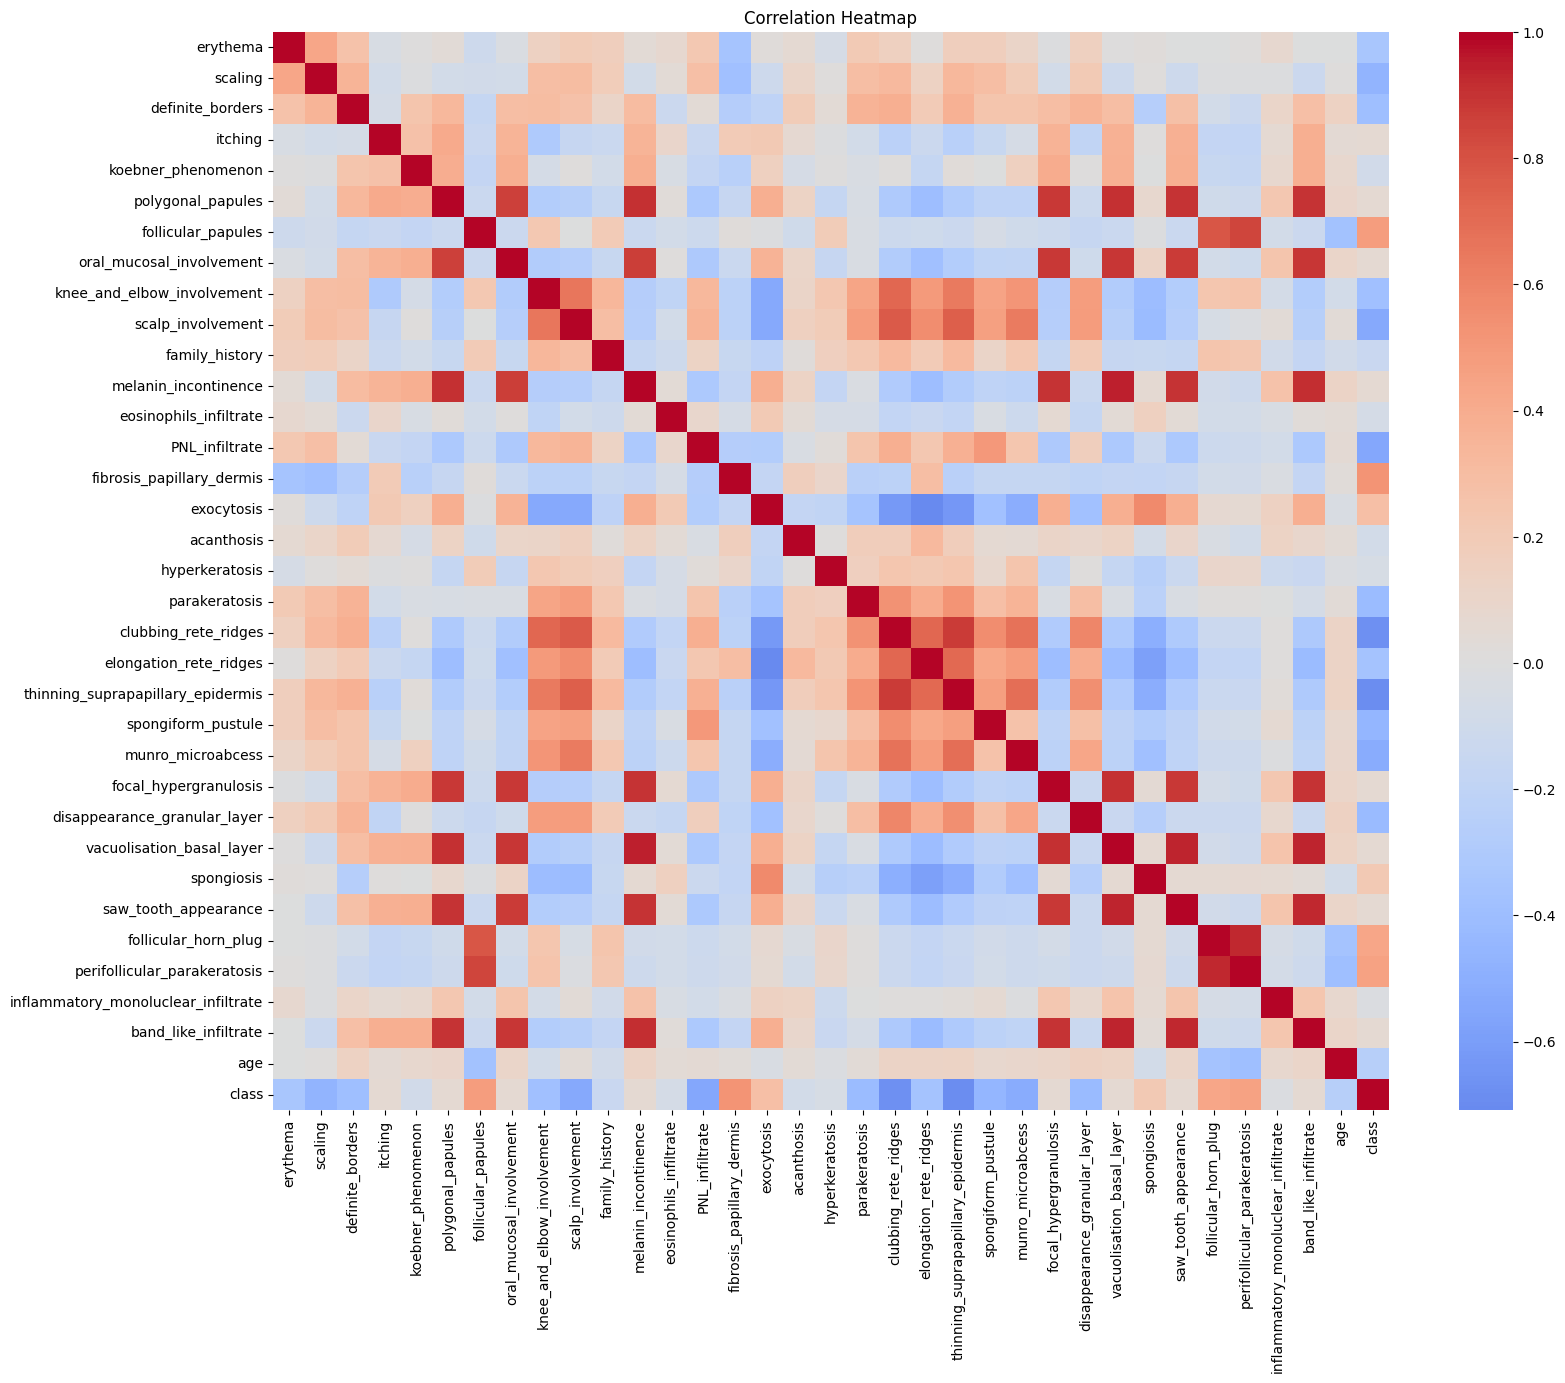

In [24]:
plt.figure(figsize=(18, 14))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
X = df.drop(columns=["class"])
y = df["class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (366, 34)
Target shape: (366,)


In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
[1 2 3 4 5 6]

Encoded classes:
[0 1 2 3 4 5]


In [27]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("80/20 SPLIT")
print("=" * 40)

print("Training samples:", len(X_train_80))
print("Testing samples:", len(X_test_80))

80/20 SPLIT
Training samples: 292
Testing samples: 74


In [28]:
scaler_80 = StandardScaler()

X_train_80_scaled = scaler_80.fit_transform(X_train_80)

X_test_80_scaled = scaler_80.transform(X_test_80)

print("80/20 data standardized successfully!")

80/20 data standardized successfully!


In [29]:
models_80 = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

print("5 models created successfully!")

5 models created successfully!


In [30]:
trained_models_80 = {}

for name, model in models_80.items():

    print(f"Training {name}...")

    model.fit(
        X_train_80_scaled,
        y_train_80
    )

    trained_models_80[name] = model

print("\nAll models trained successfully!")

Training KNN...
Training Random Forest...
Training Logistic Regression...
Training SVM...
Training Decision Tree...

All models trained successfully!


In [31]:
results_80 = []

for name, model in trained_models_80.items():

    # Predictions
    y_pred = model.predict(X_test_80_scaled)

    # Probability
    y_prob = model.predict_proba(
        X_test_80_scaled
    )

    # Metrics
    accuracy = accuracy_score(
        y_test_80,
        y_pred
    )

    precision = precision_score(
        y_test_80,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_80,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_80,
        y_pred,
        average="weighted",
        zero_division=0
    )

    auc_score = roc_auc_score(
        y_test_80,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    results_80.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc_score
    })

results_80_df = pd.DataFrame(results_80)

results_80_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.905405,0.919305,0.905405,0.908094,0.987076
1,Random Forest,0.959459,0.960688,0.959459,0.959543,0.998495
2,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.999135
3,SVM,0.972973,0.977477,0.972973,0.972973,0.998284
4,Decision Tree,0.959459,0.964619,0.959459,0.959392,0.977232


In [32]:
for name, model in trained_models_80.items():

    y_pred = model.predict(X_test_80_scaled)

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_80,
            y_pred,
            target_names=[
                class_names[i]
                for i in sorted(class_names.keys())
            ],
            zero_division=0
        )
    )



KNN
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
     Seboreic dermatitis       0.80      0.67      0.73        12
           Lichen planus       1.00      0.93      0.97        15
        Pityriasis rosea       0.64      0.90      0.75        10
       Cronic dermatitis       1.00      1.00      1.00        10
Pityriasis rubra pilaris       1.00      1.00      1.00         4

                accuracy                           0.91        74
               macro avg       0.91      0.91      0.90        74
            weighted avg       0.92      0.91      0.91        74



Random Forest
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
     Seboreic dermatitis       0.91      0.83      0.87        12
           Lichen planus       1.00      1.00      1.00        15
        Pityriasis rosea       0.82      0.90     

In [33]:
def plot_3d_confusion_matrix(
    cm,
    title,
    class_labels
):

    n_classes = len(class_labels)

    fig = plt.figure(
        figsize=(13, 10)
    )

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    # Create positions
    xpos, ypos = np.meshgrid(
        np.arange(n_classes),
        np.arange(n_classes)
    )

    xpos = xpos.flatten()
    ypos = ypos.flatten()

    zpos = np.zeros_like(xpos)

    # Bar dimensions
    dx = np.ones_like(xpos) * 0.6
    dy = np.ones_like(ypos) * 0.6

    # Bar heights
    dz = cm.flatten()

    # Draw 3D bars
    ax.bar3d(
        xpos,
        ypos,
        zpos,
        dx,
        dy,
        dz,
        shade=True
    )

    # Add values above bars
    for x, y, z in zip(
        xpos,
        ypos,
        dz
    ):

        if z > 0:

            ax.text(
                x + 0.3,
                y + 0.3,
                z + 0.5,
                str(int(z)),
                ha="center",
                va="bottom",
                fontsize=8
            )

    # Axis labels
    ax.set_xlabel(
        "Predicted Class",
        labelpad=15
    )

    ax.set_ylabel(
        "Actual Class",
        labelpad=15
    )

    ax.set_zlabel(
        "Number of Samples",
        labelpad=15
    )

    ax.set_title(
        title,
        pad=20,
        fontsize=14
    )

    # Tick positions
    ax.set_xticks(
        np.arange(n_classes) + 0.3
    )

    ax.set_yticks(
        np.arange(n_classes) + 0.3
    )

    ax.set_xticklabels(
        class_labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        class_labels
    )

    plt.tight_layout()

    plt.show()

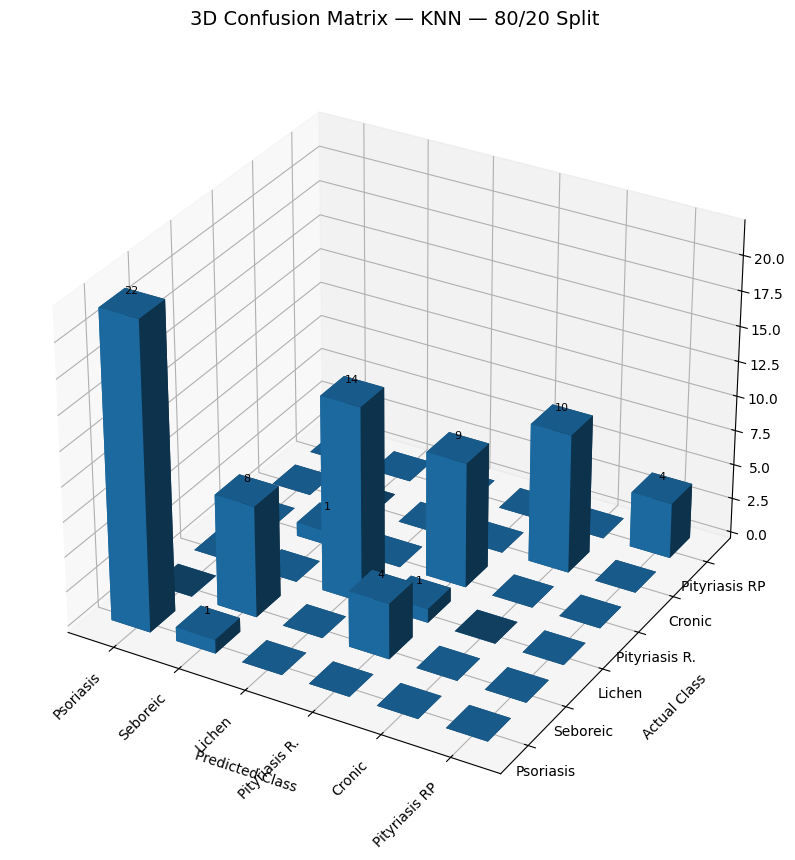

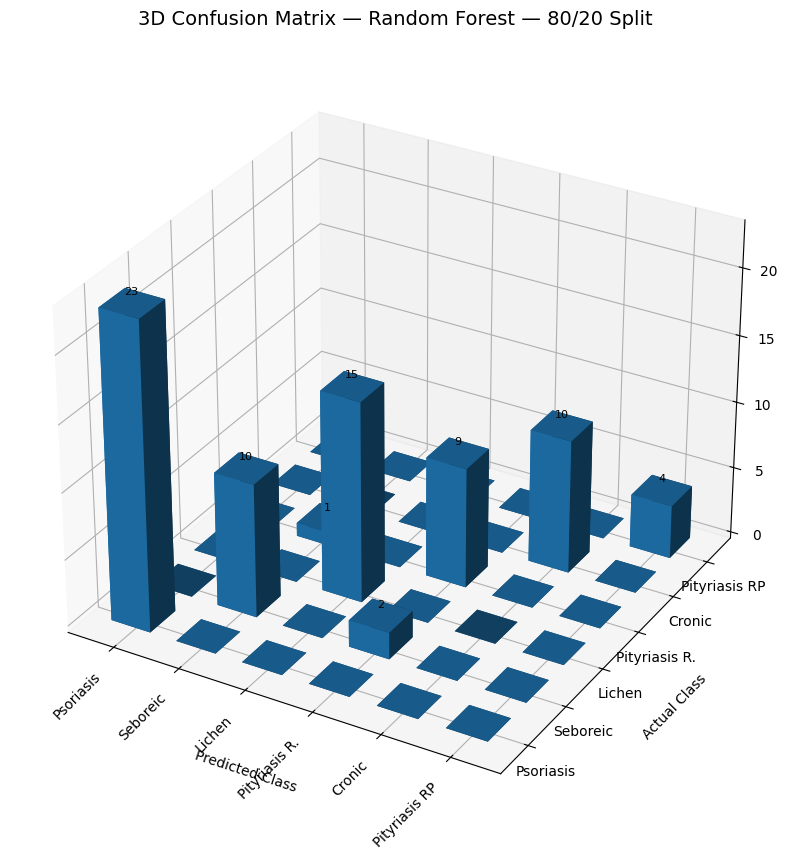

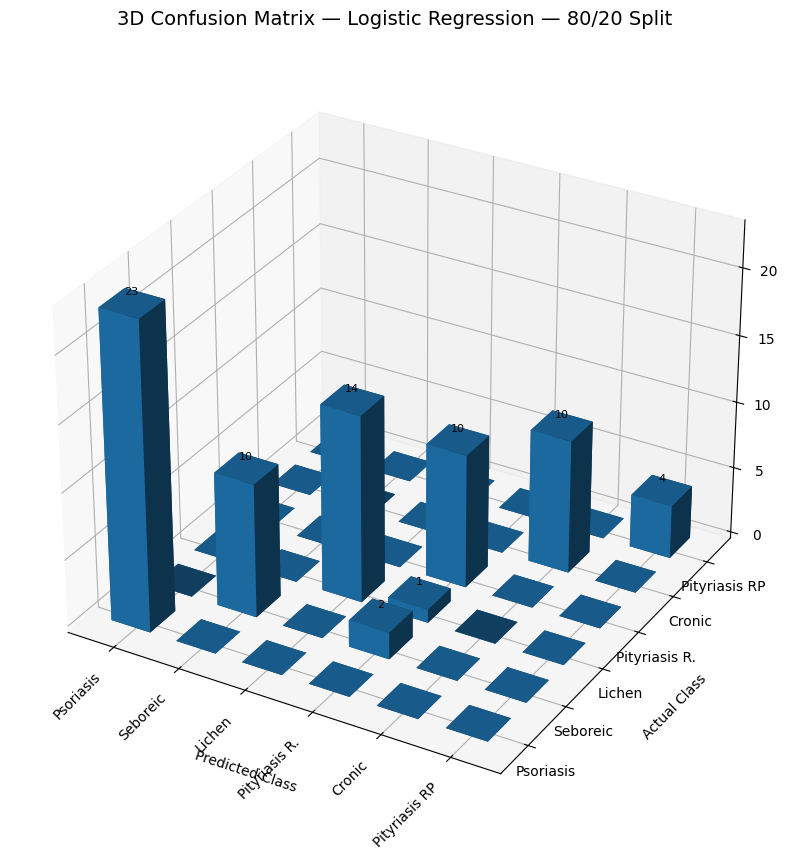

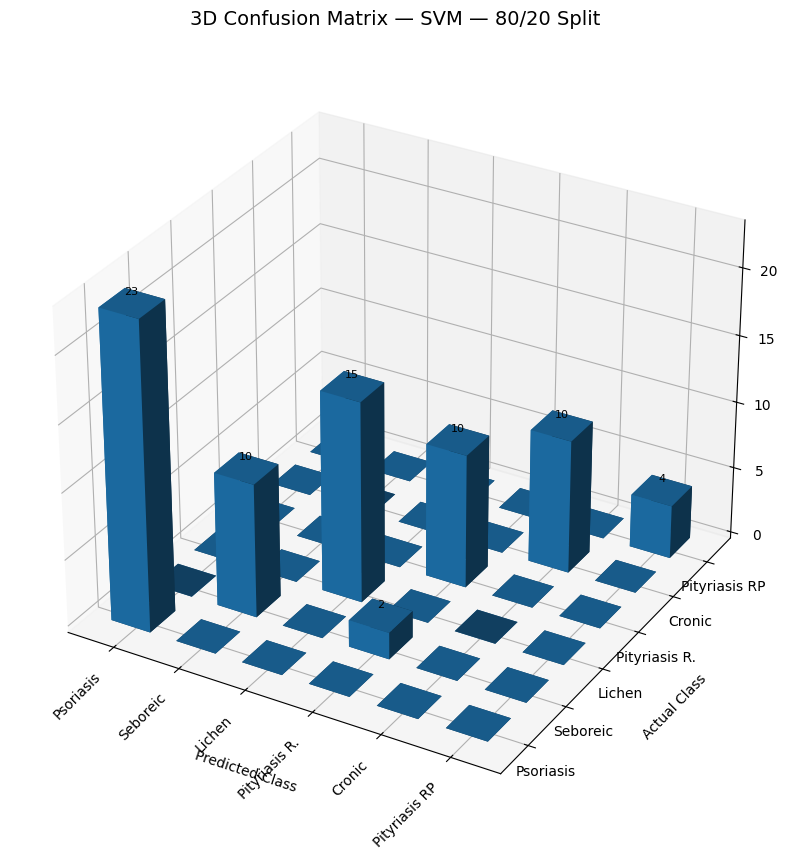

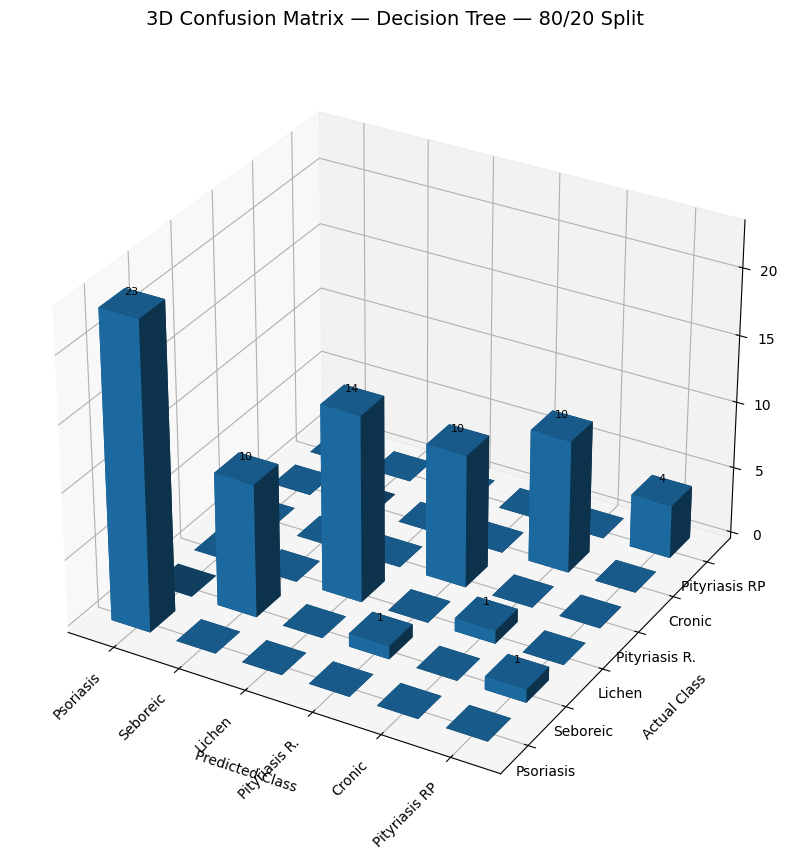

In [34]:
for name, model in trained_models_80.items():

    y_pred = model.predict(
        X_test_80_scaled
    )

    cm = confusion_matrix(
        y_test_80,
        y_pred
    )

    plot_3d_confusion_matrix(
        cm,
        f"3D Confusion Matrix — {name} — 80/20 Split",
        [
            "Psoriasis",
            "Seboreic",
            "Lichen",
            "Pityriasis R.",
            "Cronic",
            "Pityriasis RP"
        ]
    )

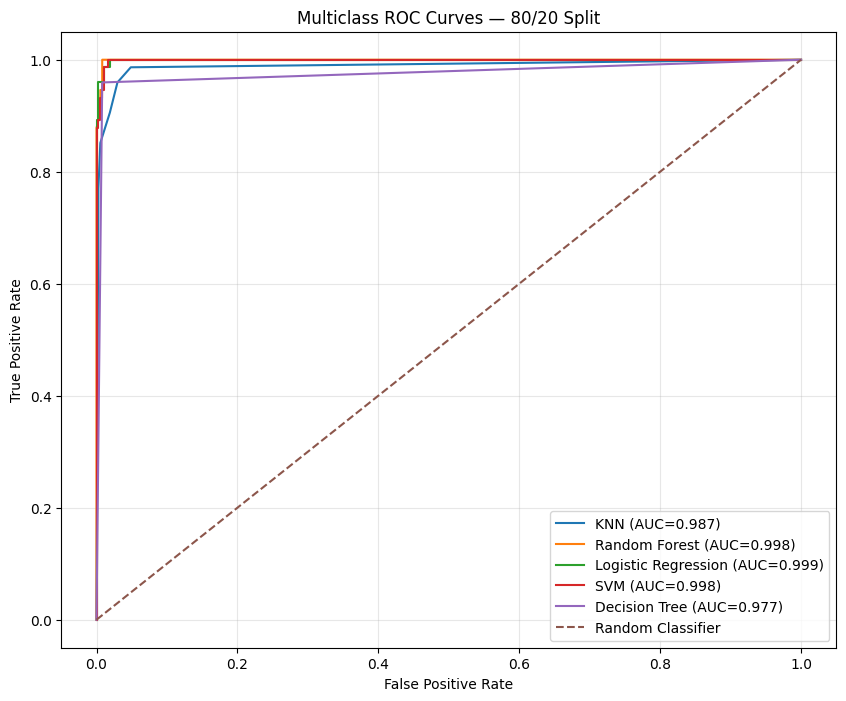

In [35]:
plt.figure(figsize=(10, 8))

for name, model in trained_models_80.items():

    y_prob = model.predict_proba(
        X_test_80_scaled
    )

    # Calculate weighted multiclass AUC
    auc_score = roc_auc_score(
        y_test_80,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    # Micro-average ROC
    y_test_binary = label_binarize(
        y_test_80,
        classes=np.arange(6)
    )

    fpr = {}
    tpr = {}

    for i in range(6):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            y_prob[:, i]
        )

    # Micro average
    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_binary.ravel(),
        y_prob.ravel()
    )

    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curves — 80/20 Split"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

<Figure size 1200x600 with 0 Axes>

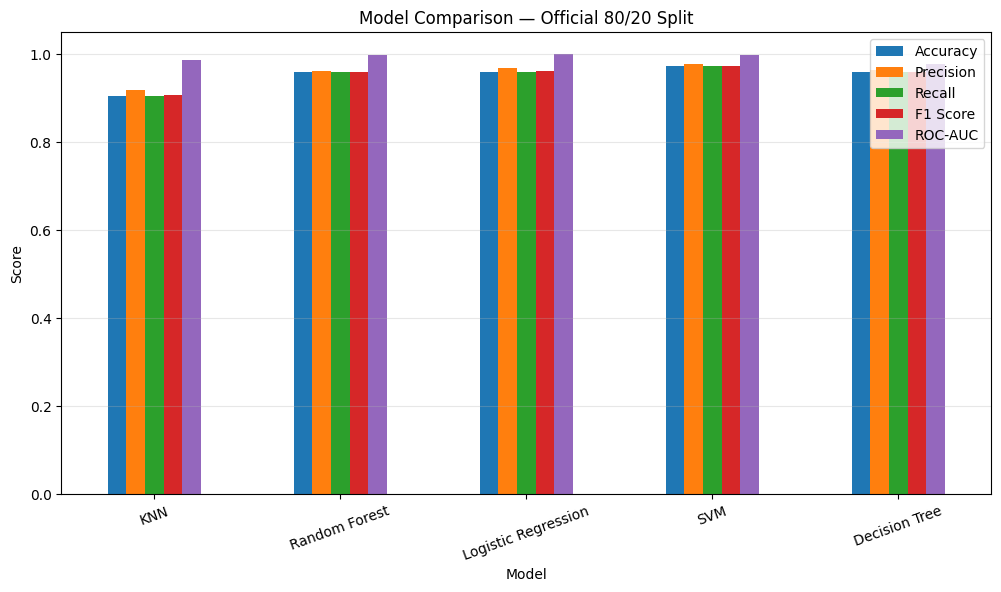

In [36]:
plt.figure(figsize=(12, 6))

results_80_plot = results_80_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

results_80_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Comparison — Official 80/20 Split"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [37]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("70/30 SPLIT")
print("=" * 40)

print("Training samples:", len(X_train_70))
print("Testing samples:", len(X_test_70))

70/30 SPLIT
Training samples: 256
Testing samples: 110


In [38]:
scaler_70 = StandardScaler()

X_train_70_scaled = scaler_70.fit_transform(
    X_train_70
)

X_test_70_scaled = scaler_70.transform(
    X_test_70
)

print("70/30 data standardized successfully!")

70/30 data standardized successfully!


In [39]:
models_70 = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

In [40]:
trained_models_70 = {}

for name, model in models_70.items():

    print(f"Training {name}...")

    model.fit(
        X_train_70_scaled,
        y_train_70
    )

    trained_models_70[name] = model

print("\nAll 70/30 models trained!")

Training KNN...
Training Random Forest...
Training Logistic Regression...
Training SVM...
Training Decision Tree...

All 70/30 models trained!


In [41]:
results_70 = []

for name, model in trained_models_70.items():

    y_pred = model.predict(
        X_test_70_scaled
    )

    y_prob = model.predict_proba(
        X_test_70_scaled
    )

    accuracy = accuracy_score(
        y_test_70,
        y_pred
    )

    precision = precision_score(
        y_test_70,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_70,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_70,
        y_pred,
        average="weighted",
        zero_division=0
    )

    auc_score = roc_auc_score(
        y_test_70,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    results_70.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc_score
    })

results_70_df = pd.DataFrame(
    results_70
)

results_70_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,0.927273,0.937273,0.927273,0.928752,0.986560
1,Random Forest,0.972727,0.973329,0.972727,0.972778,0.998926
2,Logistic Regression,0.963636,0.966310,0.963636,0.964277,0.998830
3,SVM,0.963636,0.964498,0.963636,0.963647,0.997456
4,Decision Tree,0.954545,0.957253,0.954545,0.953336,0.973341


In [42]:
for name, model in trained_models_70.items():

    y_pred = model.predict(
        X_test_70_scaled
    )

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_70,
            y_pred,
            target_names=[
                class_names[i]
                for i in sorted(class_names.keys())
            ],
            zero_division=0
        )
    )



KNN
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.97      0.99        34
     Seboreic dermatitis       0.87      0.72      0.79        18
           Lichen planus       1.00      0.95      0.98        22
        Pityriasis rosea       0.70      0.93      0.80        15
       Cronic dermatitis       1.00      1.00      1.00        15
Pityriasis rubra pilaris       1.00      1.00      1.00         6

                accuracy                           0.93       110
               macro avg       0.93      0.93      0.92       110
            weighted avg       0.94      0.93      0.93       110



Random Forest
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        34
     Seboreic dermatitis       0.94      0.89      0.91        18
           Lichen planus       1.00      1.00      1.00        22
        Pityriasis rosea       0.88      0.93     

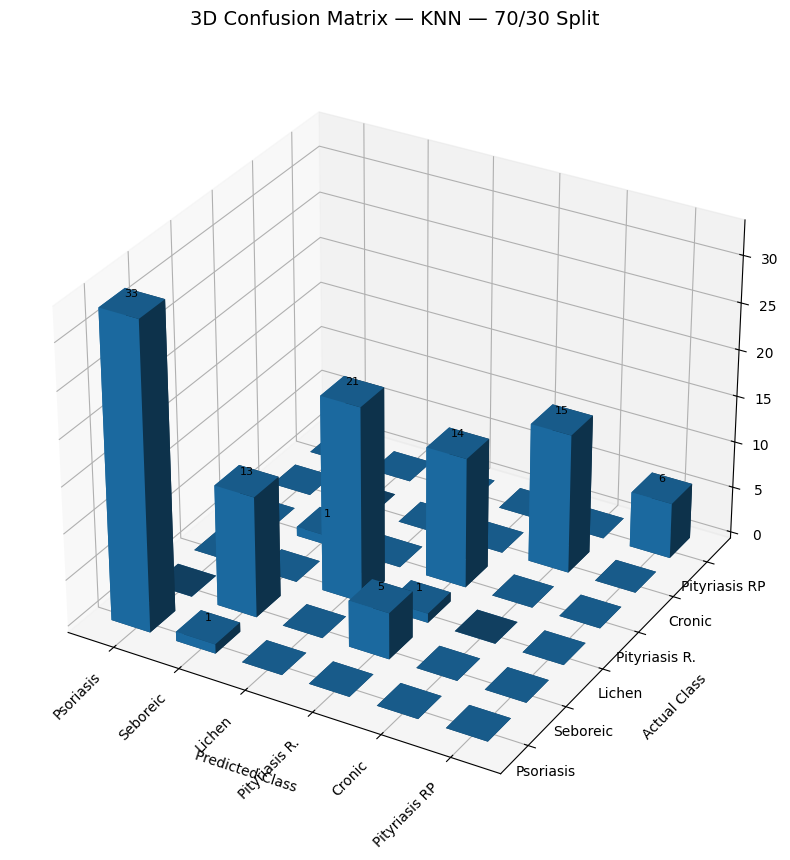

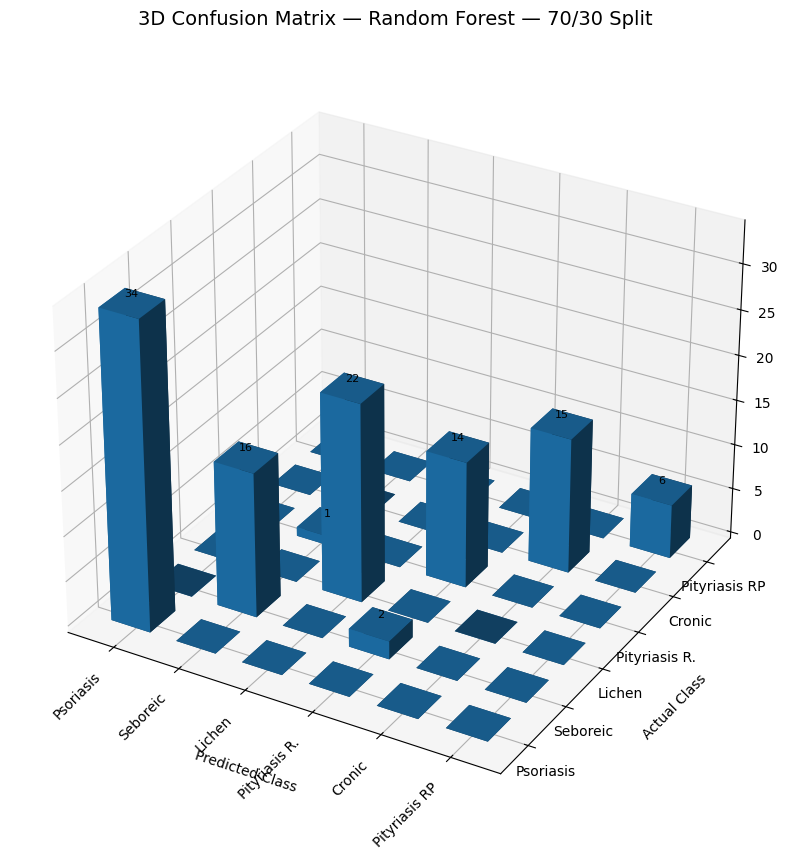

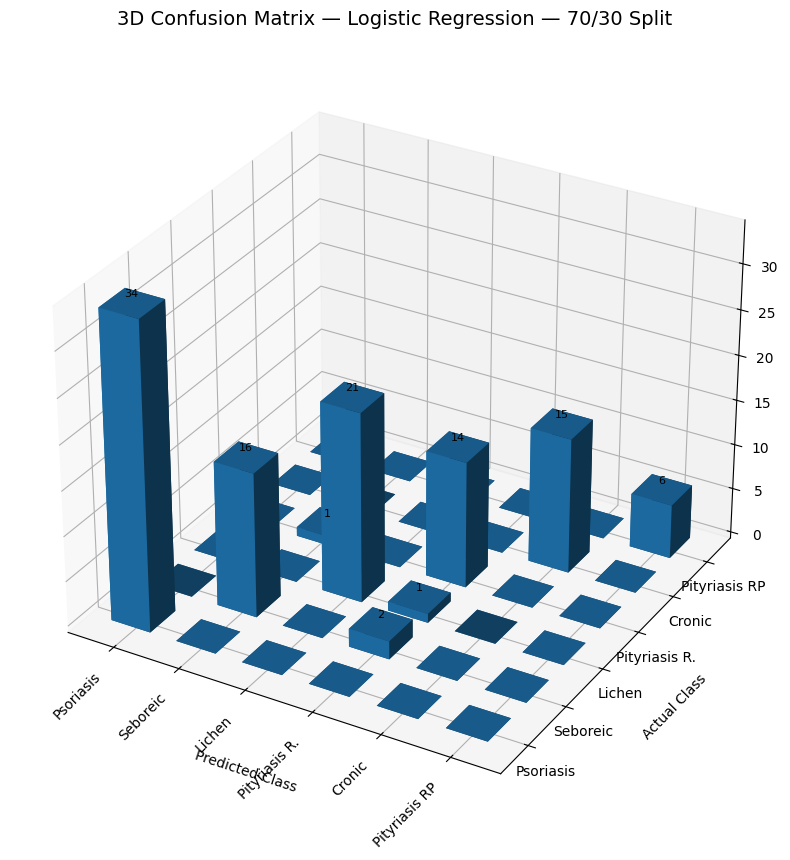

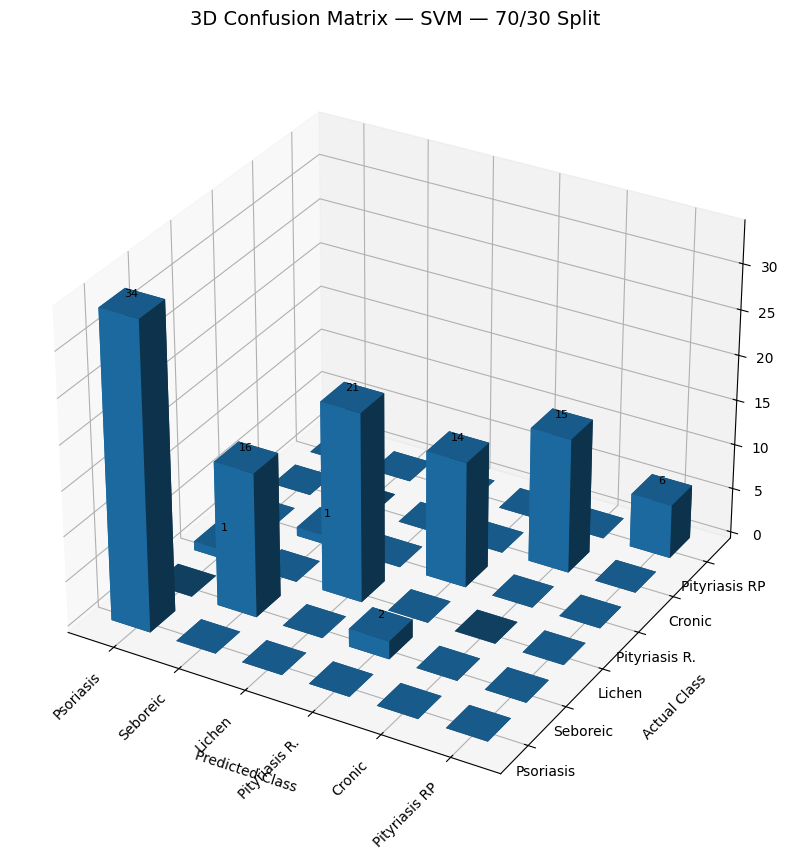

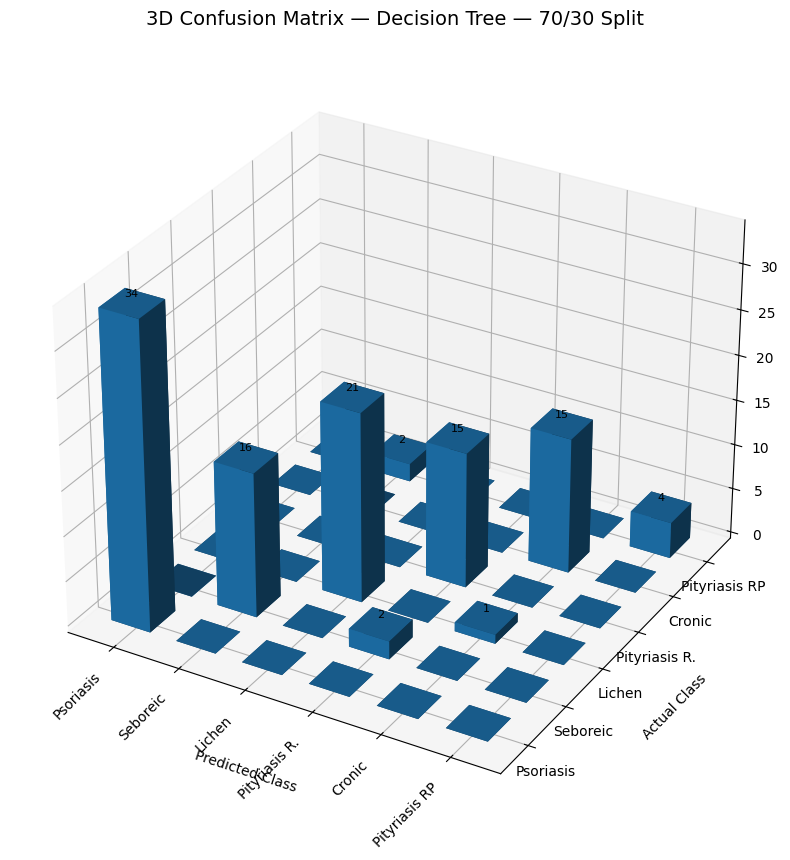

In [43]:
for name, model in trained_models_70.items():

    y_pred = model.predict(
        X_test_70_scaled
    )

    cm = confusion_matrix(
        y_test_70,
        y_pred
    )

    plot_3d_confusion_matrix(
        cm,
        f"3D Confusion Matrix — {name} — 70/30 Split",
        [
            "Psoriasis",
            "Seboreic",
            "Lichen",
            "Pityriasis R.",
            "Cronic",
            "Pityriasis RP"
        ]
    )

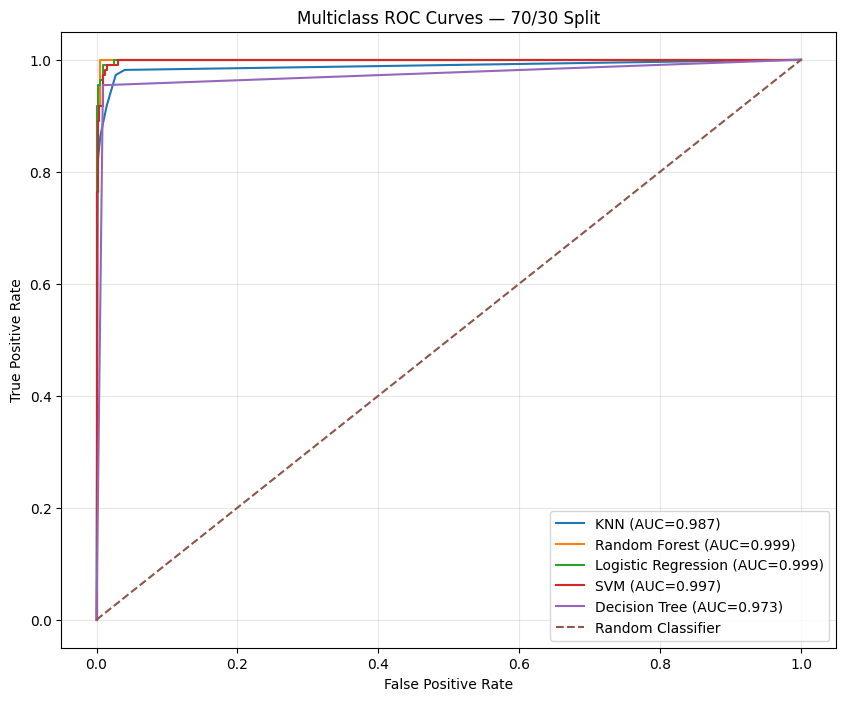

In [44]:
plt.figure(figsize=(10, 8))

y_test_binary_70 = label_binarize(
    y_test_70,
    classes=np.arange(6)
)

for name, model in trained_models_70.items():

    y_prob = model.predict_proba(
        X_test_70_scaled
    )

    auc_score = roc_auc_score(
        y_test_70,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_binary_70.ravel(),
        y_prob.ravel()
    )

    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curves — 70/30 Split"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

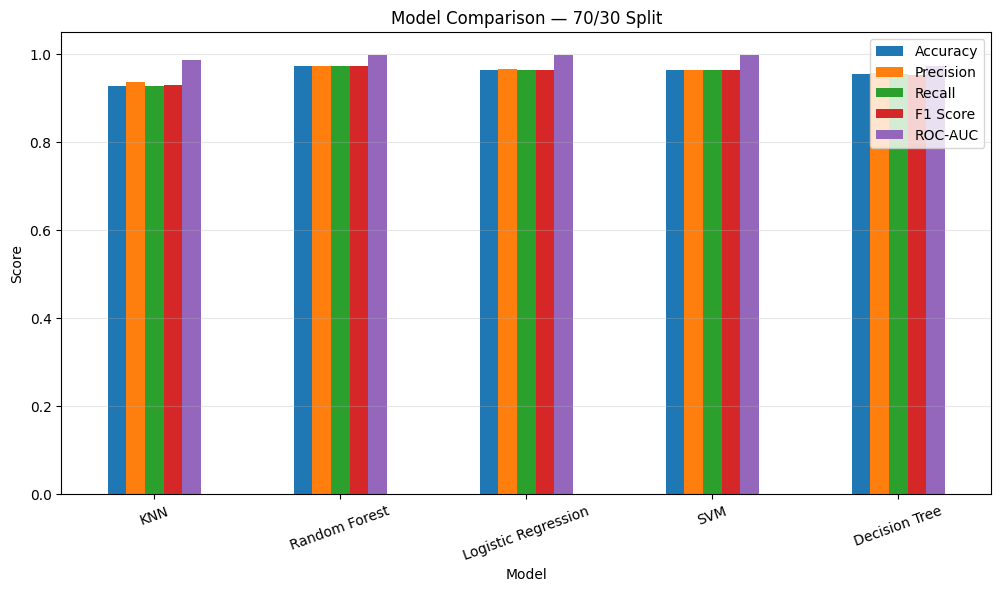

In [45]:
results_70_plot = results_70_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

results_70_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Comparison — 70/30 Split"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [46]:
comparison_all = results_80_df.merge(
    results_70_df,
    on="Model",
    suffixes=("_80_20", "_70_30")
)

comparison_all

,Model,Accuracy_80_20,Precision_80_20,Recall_80_20,F1 Score_80_20,ROC-AUC_80_20,Accuracy_70_30,Precision_70_30,Recall_70_30,F1 Score_70_30,ROC-AUC_70_30
0,KNN,0.905405,0.919305,0.905405,0.908094,0.987076,0.927273,0.937273,0.927273,0.928752,0.986560
1,Random Forest,0.959459,0.960688,0.959459,0.959543,0.998495,0.972727,0.973329,0.972727,0.972778,0.998926
2,Logistic Regression,0.959459,0.968815,0.959459,0.960642,0.999135,0.963636,0.966310,0.963636,0.964277,0.998830
3,SVM,0.972973,0.977477,0.972973,0.972973,0.998284,0.963636,0.964498,0.963636,0.963647,0.997456
4,Decision Tree,0.959459,0.964619,0.959459,0.959392,0.977232,0.954545,0.957253,0.954545,0.953336,0.973341


In [47]:
accuracy_comparison = pd.DataFrame({
    "Model": results_80_df["Model"],
    "80/20": results_80_df["Accuracy"],
    "70/30": results_70_df["Accuracy"]
})

accuracy_comparison

precision_comparison = pd.DataFrame({
    "Model": results_80_df["Model"],
    "80/20": results_80_df["Precision"],
    "70/30": results_70_df["Precision"]
})

precision_comparison

recall_comparison = pd.DataFrame({
    "Model": results_80_df["Model"],
    "80/20": results_80_df["Recall"],
    "70/30": results_70_df["Recall"]
})

recall_comparison

f1_comparison = pd.DataFrame({
    "Model": results_80_df["Model"],
    "80/20": results_80_df["F1 Score"],
    "70/30": results_70_df["F1 Score"]
})

f1_comparison

auc_comparison = pd.DataFrame({
    "Model": results_80_df["Model"],
    "80/20": results_80_df["ROC-AUC"],
    "70/30": results_70_df["ROC-AUC"]
})

auc_comparison

,Model,80/20,70/30
0,KNN,0.987076,0.986560
1,Random Forest,0.998495,0.998926
2,Logistic Regression,0.999135,0.998830
3,SVM,0.998284,0.997456
4,Decision Tree,0.977232,0.973341


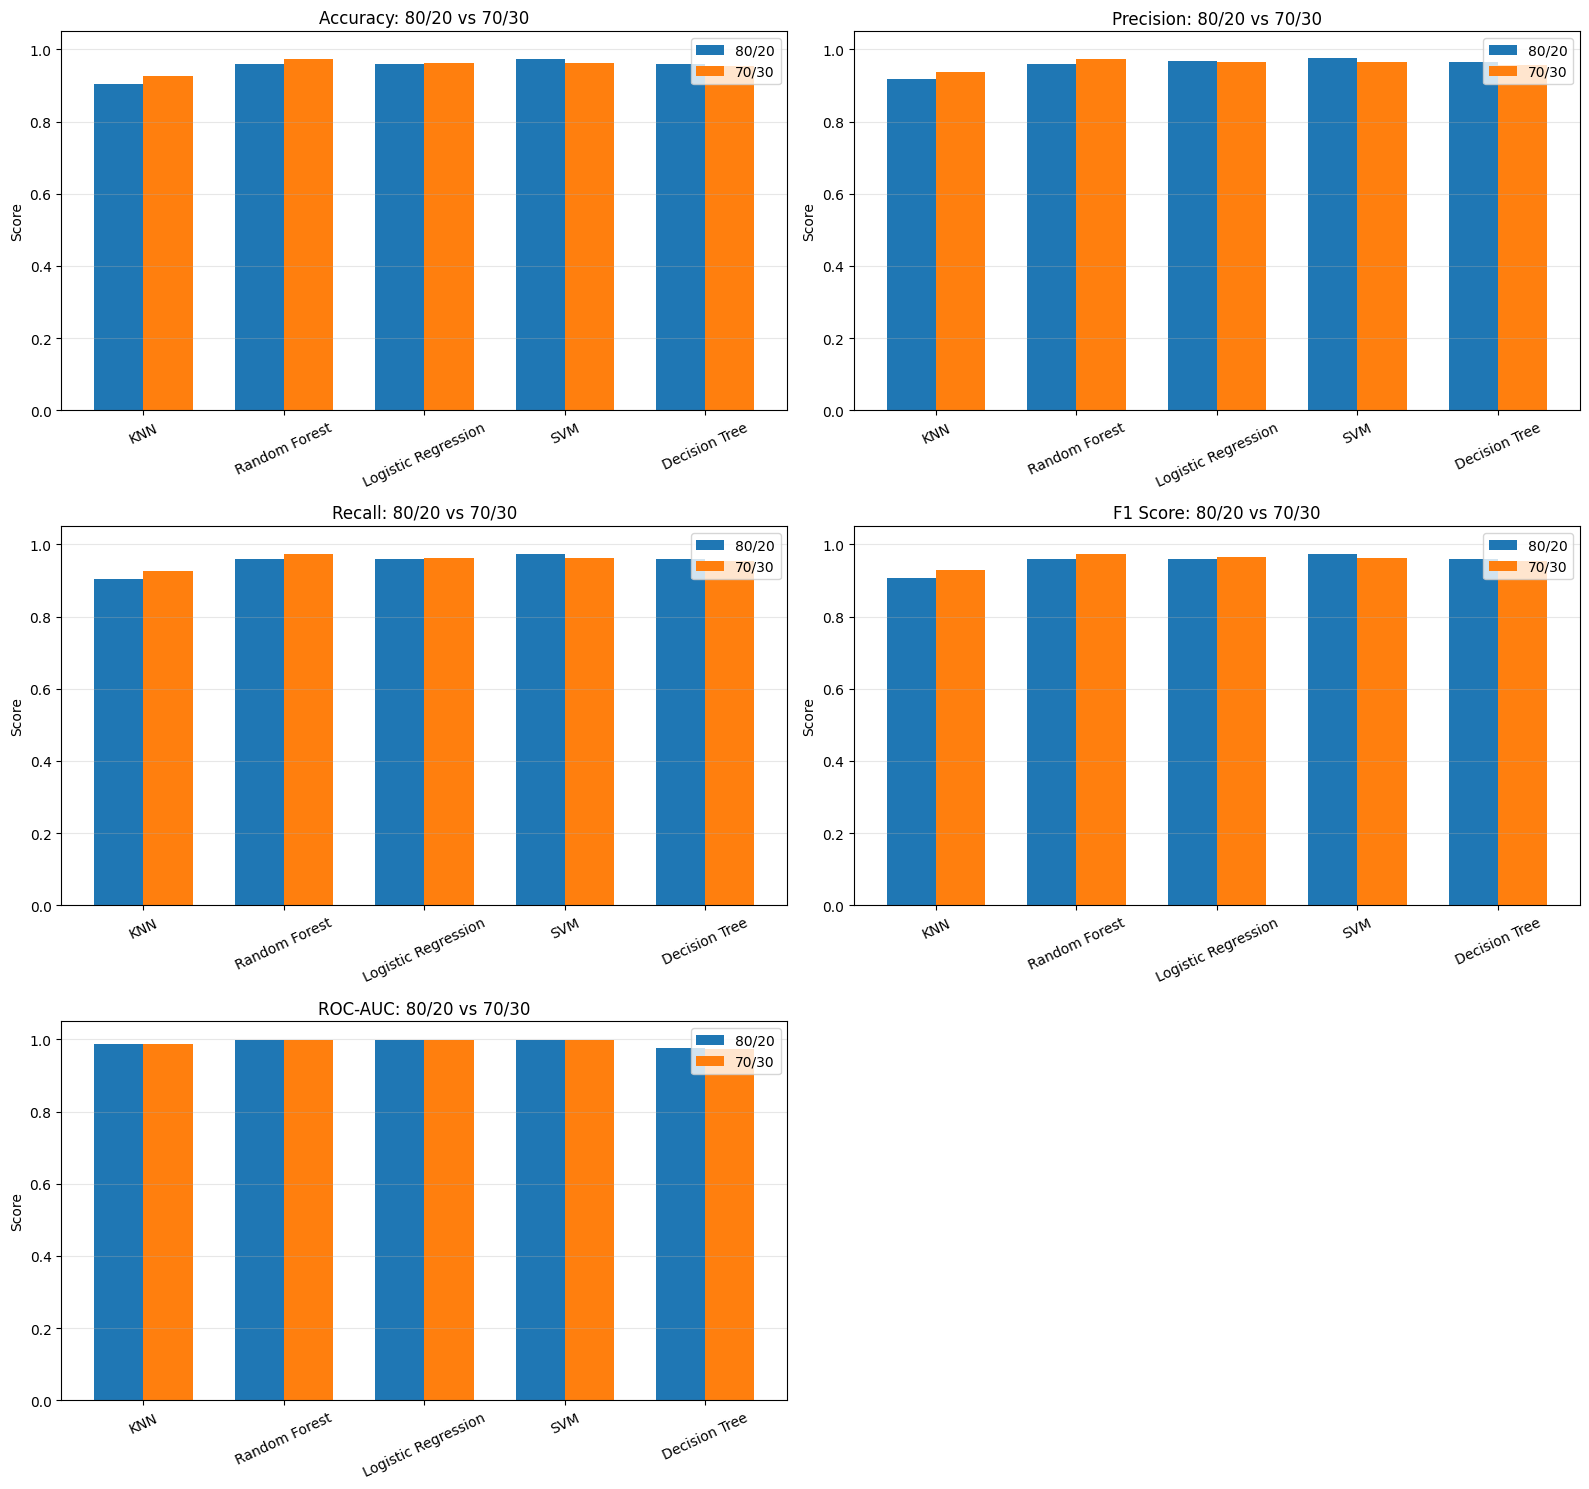

In [48]:
models = results_80_df["Model"]

x = np.arange(len(models))

width = 0.35

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 15)
)

metrics = [
    ("Accuracy", 0, 0),
    ("Precision", 0, 1),
    ("Recall", 1, 0),
    ("F1 Score", 1, 1),
    ("ROC-AUC", 2, 0)
]

for metric, row, col in metrics:

    axes[row, col].bar(
        x - width/2,
        results_80_df[metric],
        width,
        label="80/20"
    )

    axes[row, col].bar(
        x + width/2,
        results_70_df[metric],
        width,
        label="70/30"
    )

    axes[row, col].set_title(
        f"{metric}: 80/20 vs 70/30"
    )

    axes[row, col].set_xticks(x)

    axes[row, col].set_xticklabels(
        models,
        rotation=25
    )

    axes[row, col].set_ylim(0, 1.05)

    axes[row, col].set_ylabel(
        "Score"
    )

    axes[row, col].legend()

    axes[row, col].grid(
        axis="y",
        alpha=0.3
    )

# Remove unused subplot
axes[2, 1].axis("off")

plt.tight_layout()

plt.show()